In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

In [2]:
path = "D:/ML_Diffusion/md_data/c4_nmeth_frozen_double"


In [3]:
def move_to_box(x, y, z, bx, by, bz):
    # insert x, y, z coordinates as 2D arrays and move atoms into the box
    a, b = x.shape

    x_new=x.copy()
    y_new=y.copy()
    z_new=z.copy() 

    for i in range(a):
        for j in range(b):
            x_cor=x[i][j]
            if x_cor>bx/2:
                dx= int((abs(x_cor)-bx/2)/bx)+1
                x_new[i][j]=float(x_cor- (dx*bx))
            if x_cor<-bx/2:
                dx= int((abs(x_cor)-bx/2)/bx)+1
                x_new[i][j]=float(x_cor+ (dx*bx))
                
            y_cor=y[i][j]
            if (y_cor)>by/2:
                dy= int((abs(y_cor)-by/2)/by)+1
                y_new[i][j]=float(y_cor- (dy*by))
            if y_cor<-by/2:
                dy= int((abs(y_cor)-by/2)/by)+1
                y_new[i][j]=float(y_cor+ (dy*by))
            
                
            z_cor=z[i][j]
            if z_cor>bz/2:
                dz= int((abs(z_cor)-bz/2)/bz)+1
                z_new[i][j]=float(z_cor- (dz*bz))
            if z_cor<-bz/2:
                dz= int((abs(z_cor)-bz/2)/bz)+1
                z_new[i][j]=float(z_cor+ (dz*bz))

    return (x_new, y_new, z_new)


In [4]:
def dist_o_h(xo,yo,zo,xh,yh,zh):
    dist = np.sqrt((xh-xo)**2+(yh-yo)**2+(zh-zo)**2)
    return dist

In [5]:
def cal_msd(x1,y1,z1,x2,y2,z2):
    #calculates mean square displacement
    msd = np.array([0.0,0.0,0.0,0.0])
    msd[0] = ((x2-x1)**2 +(y2-y1)**2+(z2-z1)**2)
    msd[1] = (x2-x1)**2
    msd[2] = (y2-y1)**2
    msd[3] = (z2-z1)**2
    return msd

In [6]:
def gen_periodicbox(ox, x_bo, y_bo, z_bo, x_bh, y_bh, z_bh, xbox, ybox, zbox):
    #create 2D periodic box with only oxygen atoms in the system (creating 9 cells including the original box) 
    #ox: indices of Oxygen atoms in the system
    #x_bo, y_bo, z_bo: arrays containing x, y, z coordinates after moving Oxygen atoms into the box
    #x_bh, y_bh, z_bh: arrays containing x, y, z coordinates after moving Hydrogen atoms into the box
    #xbox, ybox, zbox: Dimensions of the simulation box through x, y, z axes
    
    xperiodic_ox = np.append(x_bo, x_bo, axis=0) # original and 1
    xperiodic_ox = np.append(xperiodic_ox,(x_bo +xbox),axis=0) #2
    xperiodic_ox = np.append(xperiodic_ox,(x_bo +xbox),axis=0) #3
    xperiodic_ox = np.append(xperiodic_ox,(x_bo +xbox),axis=0) #4
    xperiodic_ox = np.append(xperiodic_ox, x_bo,axis=0)  #5
    xperiodic_ox = np.append(xperiodic_ox,(x_bo -xbox),axis=0) #6
    xperiodic_ox = np.append(xperiodic_ox,(x_bo -xbox),axis=0) #7
    xperiodic_ox = np.append(xperiodic_ox,(x_bo -xbox),axis=0) #8
    
    yperiodic_ox = np.append(y_bo, (y_bo +ybox),axis=0) # original and 1
    yperiodic_ox = np.append(yperiodic_ox,(y_bo +ybox),axis=0) #2
    yperiodic_ox = np.append(yperiodic_ox,(y_bo),axis=0) #3
    yperiodic_ox = np.append(yperiodic_ox,(y_bo -ybox),axis=0) #4
    yperiodic_ox = np.append(yperiodic_ox,(y_bo -ybox),axis=0) #5
    yperiodic_ox = np.append(yperiodic_ox,(y_bo -ybox),axis=0) #6
    yperiodic_ox = np.append(yperiodic_ox,(y_bo),axis=0) #7
    yperiodic_ox = np.append(yperiodic_ox,(y_bo+ybox),axis=0) #8
    
    zperiodic_ox = (z_bo,z_bo,z_bo,z_bo,z_bo,z_bo,z_bo,z_bo,z_bo)
    zperiodic_ox = np.concatenate(zperiodic_ox)
    
    periodic_ox_indx=(ox,ox,ox,ox,ox,ox,ox,ox,ox)
    periodic_ox_indx=np.concatenate(periodic_ox_indx)
    return (periodic_ox_indx, xperiodic_ox, yperiodic_ox, zperiodic_ox)

In [7]:
def water(xo,yo,zo,xh,yh,zh,hy,periodic_ox_indx,nox,nhy):
    r_oh=np.zeros((nhy, nox*9))
    for i in range(r_oh.shape[0]): #go through Hs
        for j in range(r_oh.shape[1]):  #go through Os
            r_oh[i][j]=dist_o_h(xo[j],yo[j],zo[j],xh[i],yh[i],zh[i]) #distance between each O and H

    oh_indx = np.zeros((nhy,2), dtype=int) #for indices of O and H
    h2o = np.zeros((nox,6), dtype=int) #for water molecules

    for a in range(nhy):
        hh = r_oh[a][0] #distance with each H with first H
        oh_indx[a][0] = hy[a] #add index of each H
        oh_indx[a][1] = periodic_ox_indx[0] #add index of first Oxygen
        for b in range(1, nox*9): #go over in periodic box of Oxygen
            if r_oh[a][b]<hh: #find shotest bond
                oh_indx[a][1] = periodic_ox_indx[b]
                hh = r_oh[a][b]

    for nn in range(nox): #identify indices of atoms in water molecules
        h2o[nn][0]= periodic_ox_indx[nn] # add index of Oxygen to first column
        kk=1
        for mm in range(nhy):
            if oh_indx[mm][1]==periodic_ox_indx[nn]:
                h2o[nn][kk] = oh_indx[mm][0] #asign index of H to second/third column
                kk=kk+1
    return h2o #returns indices of O and H
    

In [8]:
def find_oh(h2o,nox,noh):
    more_oh = 0
    iik=0
    iioh = np.zeros(noh)
    iioh = iioh.astype(int)

    with open(path +'/errors.dat','w') as err_file:

        for nn in range(nox):
            if h2o[nn][2]==0: #says it is OH-
                iioh[iik] = h2o[nn][0] #asign index of O
                iik = iik+1
                more_oh = more_oh+1

            if h2o[nn][1]==0: #says it is O2-
                err_file.write('O atom found')
            
            if h2o[nn][3]>0: #says it is H3O+ 
                err_file.write('H3O+ found')

        if more_oh>noh:
            err_file.write('more than one oh')
        
            
    return iioh #returns the index of O of OH-

In [9]:
def move_than5(ll, x_o, xo_int, y_o,yo_int, xbox,ybox):
        xmv=''
        ymv=''
        #checking periodic conditions
        # atom needs to be moved to the box if it moves 5 Angstroms within 10 fs relative to the previous time step
        distx= abs(x_o-xo_int)
        disty= abs(y_o-yo_int)
        

        if distx>5: # atom need to be moved in 5 Angstroms within 10 fs
            dxx=(distx/xbox)
            dxxi=int(distx/xbox)
            if (dxx-dxxi)>0.8:
                dxxi=dxxi+1
            if x_o>xo_int:
                x_o = x_o-(xbox*dxxi)
                xmv = 'atom moved in negative x'
            elif x_o<xo_int:
                x_o= x_o+(xbox*dxxi)
                xmv = 'atom moved in positive x'
                
        if disty>5: # atom need to be moved in y
            dyy=(disty/ybox)
            dyyi=int(disty/ybox)
            if (dyy-dyyi)>0.8:
                 dyyi=dyyi+1
            if y_o>yo_int:
                y_o = y_o-(ybox*dyyi)
                ymv = 'atom moved in negative y'
            elif y_o<yo_int:
                y_o = y_o+(ybox*dyyi)
                ymv = 'atom moved in positive y'
        return (x_o, y_o, xmv, ymv)


In [10]:
def oh_identifier(nsteps, natoms, nsheet, nwater, ncat, noh, xbox, ybox, zbox):
    #number of steps in fs/MD_freq (ex: for 10 ps simulation with MD_freq=10, nsteps=10,000/10=1000)
    #natoms = total number of atoms in the sysytem
    #nsheet = total number of atoms in the graphene sheet
    #nwater = total number of water molecules
    #ncat   = total number of atoms in the cation/s
    #noh    =number of OH anions in the system
    #xbox, ybox, zbox = simulation box dimensions through x, y, z
    
    MD_freq =10 #prints after every 10 steps (10 fs)
    dt =1.0 #in fs 
    
    nox = nwater + noh
    nhy = 2*nwater + noh

    #assigning indices for moving Oxygen and Hydrogen atoms
    ox = []
    hy = []
    #mv_start = nsheet + ncat +1 #relaxed cation
    mv_start = nsheet  +1 #frozen cation 
    mv_end   = natoms +1
    for i in range(mv_start, mv_end-1, 3):
        ox.append(i)
    ox.append(i+2)
    for j in range(mv_start, mv_end, 1):
        if j not in ox:
            hy.append(j)
    
            
    #reading xyz coordinates related to Oxygens and Hydrogens
    x_h= np.zeros((nhy,nsteps))
    y_h= np.zeros((nhy,nsteps))
    z_h= np.zeros((nhy,nsteps))

    x_o= np.zeros((nox,nsteps))
    y_o= np.zeros((nox,nsteps))
    z_o= np.zeros((nox,nsteps))


    with open(path +'/geo_end.xyz', 'r') as out_file:
        xyz= out_file.readlines()
        for i in range(nsteps):
            end = (i+1)*(natoms+2)
            start= end - natoms
            io=0
            ih=0
            for j in ox:
                oindx = start+j-1
                x_o[io][i]=float(xyz[oindx].split()[1])
                y_o[io][i]=float(xyz[oindx].split()[2])
                z_o[io][i]=float(xyz[oindx].split()[3])
                io=io+1
            for k in hy:
                hindx = start+k-1
                x_h[ih][i]=float(xyz[hindx].split()[1])
                y_h[ih][i]=float(xyz[hindx].split()[2])
                z_h[ih][i]=float(xyz[hindx].split()[3])
                ih = ih+1

    x_bo, y_bo, z_bo = move_to_box(x_o, y_o, z_o, xbox, ybox, zbox)
    x_bh, y_bh, z_bh = move_to_box(x_h, y_h, z_h, xbox, ybox, zbox)

    periodic_ox_indx, xperiodic_ox, yperiodic_ox, zperiodic_ox = gen_periodicbox(ox, x_bo, y_bo, z_bo, x_bh, y_bh, z_bh,xbox, ybox, zbox)

    x_oh1 = np.zeros(nsteps)
    y_oh1 = np.zeros(nsteps)
    z_oh1 = np.zeros(nsteps)
    indx_oh1 = np.zeros(nsteps)

    x_oh2 = np.zeros(nsteps)
    y_oh2 = np.zeros(nsteps)
    z_oh2 = np.zeros(nsteps)
    indx_oh2 = np.zeros(nsteps)

    msd_oh=np.zeros(nsteps)
    msd_ohx=np.zeros(nsteps)
    msd_ohy=np.zeros(nsteps)
    msd_ohz=np.zeros(nsteps)


    rattle = open(path+"/rattle.dat", "w")
    for ll in range(nsteps):
        xo = [sub[ll] for sub in xperiodic_ox]
        yo = [sub[ll] for sub in yperiodic_ox]
        zo = [sub[ll] for sub in zperiodic_ox]
        xh = [sub[ll] for sub in x_bh]
        yh = [sub[ll] for sub in y_bh]
        zh = [sub[ll] for sub in z_bh]
        h2o = water(xo,yo,zo,xh,yh,zh,hy,periodic_ox_indx,nox,nhy)
        indx_o = find_oh(h2o,nox,noh) #index of O of OH-
        indx_ox1 =ox.index(indx_o[0]) #index of ox array corresponding to real indx_o
        indx_ox2 =ox.index(indx_o[1]) 

        if ll>0:
            if (indx_o[0]== indx_oold[1]) or (indx_o[1]== indx_oold[0]):
                hhh = indx_o[0].copy()
                indx_o[0] = indx_o[1].copy()
                indx_o[1] = hhh.copy()
                indx_ox1 =ox.index(indx_o[0]) #index of ox array corresponding to real indx_o
                indx_ox2 =ox.index(indx_o[1]) 
                
            if indx_o[0]!=indx_oold[0]:
                ohh, = np.where(h2o == indx_oold[0])[0]
                h11 = h2o[ohh][1] #h1 on old oh1
                h12 = h2o[ohh][2] #h2 on old oh1
                if h11 == h2o_old[ohh][1]: # find jumped H
                    jmpd_oh = h12
                else:
                    jmpd_oh = h11
                indx_ox1, = np.where(h2o_old == jmpd_oh)[0]
                indx_o[0] = ox[indx_ox1]

            if indx_o[1]!=indx_oold[1]:
                ohh, = np.where(h2o == indx_oold[1])[0]
                h21 = h2o[ohh][1] #h1 on old oh2
                h22 = h2o[ohh][2] #h2 on old oh2
                if h21 == h2o_old[ohh][1]: # find jumped H
                    jmpd_oh = h22
                else:
                    jmpd_oh = h21
                indx_ox2, = np.where(h2o_old == jmpd_oh)[0]
                indx_o[1] = ox[indx_ox2]

        h2o_old=h2o
        indx_oold=indx_o
        
        if ll==0:
            xo_01 = x_o[indx_ox1][0]
            yo_01 = y_o[indx_ox1][0]
            zo_01 = z_o[indx_ox1][0]
            xo_02 = x_o[indx_ox2][0]
            yo_02 = y_o[indx_ox2][0]
            zo_02 = z_o[indx_ox2][0]
            
            xo1_int= x_o[indx_ox1][ll]
            yo1_int= y_o[indx_ox1][ll]
            xo2_int= x_o[indx_ox2][ll]
            yo2_int= y_o[indx_ox2][ll]

        xmv1 = ' no_x1 '
        ymv1 = ' no_y1 '
        xmv2 = ' no_x2 '
        ymv2 = ' no_y2 '
        
        #print step and initial OH1 and OH2 identities and xyz coordinates
        #print(ll, indx_o[0], x_o[indx_ox1][ll], y_o[indx_ox1][ll], z_o[indx_ox1][ll], indx_o[1], x_o[indx_ox2][ll], y_o[indx_ox2][ll], z_o[indx_ox2][ll],"OH")


    ####if OHs are mixed up change the identity of  OH    
        if ((x_o[indx_ox1][ll]-xo1_int)**2+(y_o[indx_ox1][ll]-yo1_int)**2)>16 and ((x_o[indx_ox2][ll]-xo2_int)**2+(y_o[indx_ox2][ll]-yo2_int)**2)>16:
            switch = indx_ox1
            indx_ox1 = indx_ox2
            indx_ox1 = switch
            indx_o[0] = ox[indx_ox1]
            indx_o[1] = ox[indx_ox2]
            rattle.write('-------------switch OH---------------------------'+ '\n')      

        x_o[indx_ox1][ll], y_o[indx_ox1][ll], xmv1, ymv1=move_than5(ll, x_o[indx_ox1][ll], xo1_int, y_o[indx_ox1][ll],yo1_int, xbox,ybox)
        x_o[indx_ox2][ll], y_o[indx_ox2][ll], xmv2, ymv2=move_than5(ll, x_o[indx_ox2][ll], xo2_int, y_o[indx_ox2][ll],yo2_int, xbox,ybox)
                
        xo1_int= x_o[indx_ox1][ll]
        yo1_int= y_o[indx_ox1][ll]
        xo2_int= x_o[indx_ox2][ll]
        yo2_int= y_o[indx_ox2][ll]

        x_oh1[ll] = x_o[indx_ox1][ll]
        y_oh1[ll] = y_o[indx_ox1][ll]
        z_oh1[ll] = z_o[indx_ox1][ll]

        x_oh2[ll] = x_o[indx_ox2][ll]
        y_oh2[ll] = y_o[indx_ox2][ll]
        z_oh2[ll] = z_o[indx_ox2][ll]

###################################for OH1########################################
        indx_oh1[ll] = indx_o[0]
        if (indx_oh1[ll]==indx_oh1[(ll-20)]) and (indx_oh1[ll]!=indx_oh1[(ll-1)]): # remove rattaling
            xmv1 = ' no change '
            ymv1 = ' no change '
            indx_rox =ox.index(indx_oh1[ll]) #index of ox array corresponding to real indx_oh[ll]
            rattle.write('rattling1 for OH1 starts here'+'\n')

            for llk in range((ll-19),ll):
                x_oh1[llk] = x_o[indx_rox][llk]
                y_oh1[llk] = y_o[indx_rox][llk]
                z_oh1[llk] = z_o[indx_rox][llk]
                indx_oh1[llk] = indx_oh1[ll]

                x_oh1[llk], y_oh1[llk], xmv1, ymv1=move_than5(llk, x_oh1[llk], x_oh1[llk-1], y_oh1[llk],y_oh1[llk-1], xbox,ybox)
                    
                rattle.write('{:<6d}'.format(llk)+'{:<6d}'.format(int(indx_oh1[llk]))+'{0: >#016.8f}'.format(x_oh1[llk])+'{0: >#016.8f}'.format(y_oh1[llk])+'{0: >#016.8f}'.format(z_oh1[llk])+xmv1+ymv1 + '\n')  
             
            xo1_int = x_oh1[llk-1]
            y01_int = y_oh1[llk-1]
            rattle.write('rattaling1 for OH1 ends here'+'\n')

        # remove rattling just after hopping (50 fs)
        if (indx_oh1[ll]==indx_oh1[(ll-5)]) and (indx_oh1[ll]!=indx_oh1[(ll-1)]): 
            xmv1 = ' no change '
            ymv1 = ' no change '
         
            indx_hox =ox.index(indx_oh1[ll]) #index of ox array corresponding to real indx_oh[ll]
            rattle.write('rattling2 for OH1 starts here' + '\n')
            
            for llk in range((ll-4), ll):
                x_oh1[llk] = x_o[indx_hox][llk]
                y_oh1[llk] = y_o[indx_hox][llk]
                z_oh1[llk] = z_o[indx_hox][llk]
                indx_oh1[llk] = indx_oh1[ll]

                x_oh1[llk], y_oh1[llk], xmv1, ymv1=move_than5(llk, x_oh1[llk], x_oh1[llk-1], y_oh1[llk],y_oh1[llk-1], xbox,ybox)
                    
                rattle.write('{:<6d}'.format(llk)+'{:<6d}'.format(int(indx_oh1[llk]))+'{0: >#016.8f}'.format(x_oh1[llk])+'{0: >#016.8f}'.format(y_oh1[llk])+'{0: >#016.8f}'.format(z_oh1[llk])+xmv1+ymv1+'\n')  
            
            xo1_int = x_oh1[llk-1]
            y01_int = y_oh1[llk-1]
            rattle.write('rattling2 for OH1 ends here'+'\n')    
            
###################################for OH2########################################
        indx_oh2[ll] = indx_o[1]
        if (indx_oh2[ll]==indx_oh2[(ll-20)]) and (indx_oh2[ll]!=indx_oh2[(ll-1)]): # remove rattaling
            xmv2 = ' no change '
            ymv2 = ' no change '
            indx_rox =ox.index(indx_oh2[ll]) #index of ox array corresponding to real indx_oh[ll]
            rattle.write('rattling1 for OH2 starts here'+'\n')

            for llk in range((ll-19),ll):
                x_oh2[llk] = x_o[indx_rox][llk]
                y_oh2[llk] = y_o[indx_rox][llk]
                z_oh2[llk] = z_o[indx_rox][llk]
                indx_oh2[llk] = indx_oh2[ll]

                x_oh2[llk], y_oh2[llk], xmv2, ymv2=move_than5(llk, x_oh2[llk], x_oh2[llk-1], y_oh2[llk],y_oh2[llk-1], xbox,ybox)
                    
                rattle.write('{:<6d}'.format(llk)+'{:<6d}'.format(int(indx_oh2[llk]))+'{0: >#016.8f}'.format(x_oh2[llk])+'{0: >#016.8f}'.format(y_oh2[llk])+'{0: >#016.8f}'.format(z_oh2[llk])+xmv2+ymv2+'\n')  
             
            xo2_int = x_oh2[llk-1]
            y02_int = y_oh2[llk-1]
            rattle.write('rattaling1 for OH2 ends here'+'\n')

        # remove rattling just after hopping (50 fs)
        if (indx_oh2[ll]==indx_oh2[(ll-5)]) and (indx_oh2[ll]!=indx_oh2[(ll-1)]): 
            xmv2 = ' no change '
            ymv2 = ' no change '
         
            indx_hox =ox.index(indx_oh2[ll]) #index of ox array corresponding to real indx_oh[ll]
            rattle.write('rattling2 for OH2 starts here'+'\n')
            
            for llk in range((ll-4), ll):
                x_oh2[llk] = x_o[indx_hox][llk]
                y_oh2[llk] = y_o[indx_hox][llk]
                z_oh2[llk] = z_o[indx_hox][llk]
                indx_oh2[llk] = indx_oh2[ll]

                x_oh2[llk], y_oh2[llk], xmv2, ymv2=move_than5(llk, x_oh2[llk], x_oh2[llk-1], y_oh2[llk],y_oh2[llk-1], xbox,ybox)
                    
                rattle.write('{:<6d}'.format(llk)+'{:<6d}'.format(int(indx_oh2[llk]))+'{0: >#016.8f}'.format(x_oh2[llk])+'{0: >#016.8f}'.format(y_oh2[llk])+'{0: >#016.8f}'.format(z_oh2[llk])+xmv2,ymv2+'\n')  
                
            xo2_int = x_oh2[llk-1]
            y02_int = y_oh2[llk-1]
            rattle.write('rattling2 for OH2 ends here'+'\n')  

# check OH swap

        if (indx_oh1[ll]==indx_oh2[(ll-20)]):
            err= open(path+"/Error_oh.dat", "w")
            err.write('OH1 and OH2 can be mislabeled'+'\n')
            err.write('---------------------------------------'+'\n')
            err.close()

    rattle.close()

    return(xo_01, yo_01, zo_01, indx_oh1, x_oh1,y_oh1,z_oh1, xo_02, yo_02, zo_02, indx_oh2, x_oh2, y_oh2, z_oh2)
    
     


In [11]:
###########################################################(nsteps, natoms, nsheet, nwater, ncat, noh, xbox,     ybox, zbox)
xo_01, yo_01, zo_01, indx_oh1, x_oh1,y_oh1,z_oh1, xo_02, yo_02, zo_02, indx_oh2, x_oh2, y_oh2, z_oh2=oh_identifier(1001,      574,    480,     30, 25,     2, 22.797, 13.392, 15.0) 

oh_msd = pd.DataFrame(columns=['nstep', 'msd_oh', 'msd_ohx', 'msd_ohy', 'msd_ohz'])
nsteps=len(x_oh1)
# msd_oh=np.zeros(nsteps)
# msd_ohx=np.zeros(nsteps)
# msd_ohy=np.zeros(nsteps)
# msd_ohz=np.zeros(nsteps)

with open(path +'/oh1_id.dat', 'w') as oh1_id:
    for i in range(nsteps):
        # msd_oh[i], msd_ohx[i], msd_ohy[i], msd_ohz[i] = cal_msd(oh_x0,oh_y0, oh_z0,x_oh[i],y_oh[i],z_oh[i])
                    
        # oh_msd.loc[i,"nstep"]= i+1
        # oh_msd.loc[i,"msd_oh"]= msd_oh[i]
        # oh_msd.loc[i,"msd_ohx"]= msd_ohx[i]
        # oh_msd.loc[i,"msd_ohy"]= msd_ohy[i]
        # oh_msd.loc[i,"msd_ohz"]= msd_ohz[i]
    
        oh1_id.write('{:<6d}'.format(i) +'{:<6d}'.format(int(indx_oh1[i]))+'{0: >#016.8f}'.format(x_oh1[i])+'{0: >#016.8f}'.format(y_oh1[i])+'{0: >#016.8f}'.format(z_oh1[i])+'\n')
#oh_msd.to_csv(path+"oh_msd.csv", index=False)
with open(path +'/oh2_id.dat', 'w') as oh2_id:
    for i in range(nsteps):
        oh2_id.write('{:<6d}'.format(i) +'{:<6d}'.format(int(indx_oh2[i]))+'{0: >#016.8f}'.format(x_oh2[i])+'{0: >#016.8f}'.format(y_oh2[i])+'{0: >#016.8f}'.format(z_oh2[i])+'\n')

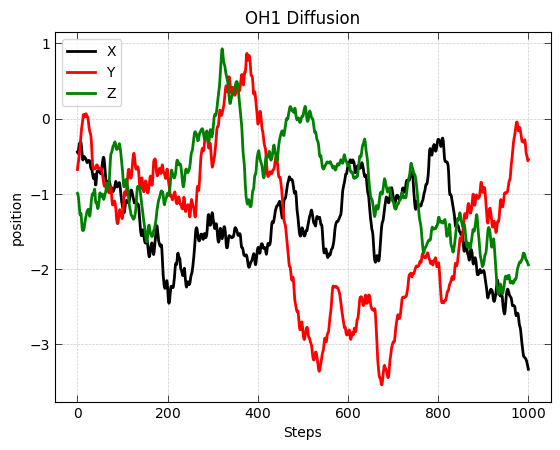

In [12]:
plt.figure()
plt.plot(x_oh1[:],color='black',linewidth=2,label="X")
plt.plot(y_oh1[:],color='r',linewidth=2,label="Y")
plt.plot(z_oh1[:],color='g',linewidth=2,label="Z")
plt.legend(loc="upper left")
plt.xlabel('Steps')
plt.ylabel('position')
plt.title("OH1 Diffusion")
plt.tick_params(axis="x",which='major', direction="in", length=5, width=0.5)
plt.tick_params(axis="y",which='major',direction="in", length=5, width=0.5)
plt.tick_params(axis="x",which='minor', direction="in", length=5, width=0.5)
plt.tick_params(axis="y",which='minor',direction="in", length=5, width=0.5)
plt.grid(which='major',color='#CCCCCC', linestyle='--', linewidth=0.5)
plt.ticklabel_format(axis="x", style="plain", scilimits=(0,0),useMathText=True)
#plt.ylim([0,80])
plt.tick_params(bottom=True, top=True, left=True, right=True)
plt.savefig(path +'/oh1.jpg', dpi=100) 

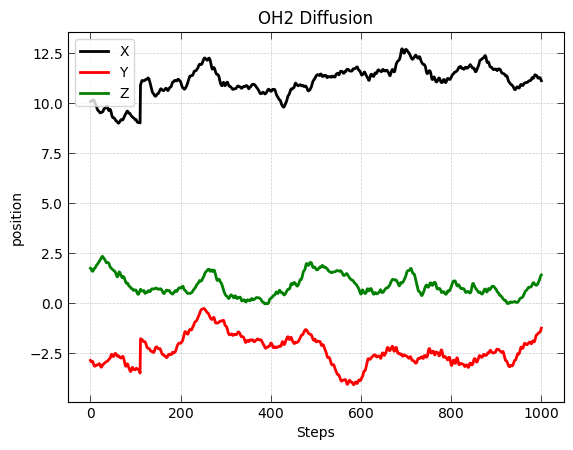

In [13]:
plt.figure()
plt.plot(x_oh2[:],color='black',linewidth=2,label="X")
plt.plot(y_oh2[:],color='r',linewidth=2,label="Y")
plt.plot(z_oh2[:],color='g',linewidth=2,label="Z")
plt.legend(loc="upper left")
plt.xlabel('Steps')
plt.ylabel('position')
plt.title("OH2 Diffusion")
plt.tick_params(axis="x",which='major', direction="in", length=5, width=0.5)
plt.tick_params(axis="y",which='major',direction="in", length=5, width=0.5)
plt.tick_params(axis="x",which='minor', direction="in", length=5, width=0.5)
plt.tick_params(axis="y",which='minor',direction="in", length=5, width=0.5)
plt.grid(which='major',color='#CCCCCC', linestyle='--', linewidth=0.5)
plt.ticklabel_format(axis="x", style="plain", scilimits=(0,0),useMathText=True)
#plt.ylim([0,80])
plt.tick_params(bottom=True, top=True, left=True, right=True)
plt.savefig(path +'/oh2.jpg', dpi=100) 